In [1]:
import pandas as pd
import numpy as np
import string

In [2]:
text = 'Stay up-to-date with the latest Artemis content from NASA as we explore the Moon for scientific discovery and to prepare for human missions to Mars.'

In [3]:
!pip install deep-translator

In [4]:
from deep_translator import GoogleTranslator

translator = GoogleTranslator(source='en', target='ru')
translation_text = translator.translate(text)

In [5]:
print(f"EN: {text}")
print(f"RU: {translation_text}")

EN: Stay up-to-date with the latest Artemis content from NASA as we explore the Moon for scientific discovery and to prepare for human missions to Mars.
RU: Будьте в курсе последних новостей об Артемиде от НАСА, пока мы исследуем Луну для научных открытий и готовимся к полетам человека на Марс.


In [6]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.stem import WordNetLemmatizer

In [7]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [8]:
tokens = word_tokenize(text)

In [9]:
tokens

['Stay',
 'up-to-date',
 'with',
 'the',
 'latest',
 'Artemis',
 'content',
 'from',
 'NASA',
 'as',
 'we',
 'explore',
 'the',
 'Moon',
 'for',
 'scientific',
 'discovery',
 'and',
 'to',
 'prepare',
 'for',
 'human',
 'missions',
 'to',
 'Mars',
 '.']

In [10]:
stop_words = set(stopwords.words('english'))
stop_words.update(['.'])
filtered = [word.lower() for word in tokens if word.lower() not in stop_words]

In [11]:
filtered

['stay',
 'up-to-date',
 'latest',
 'artemis',
 'content',
 'nasa',
 'explore',
 'moon',
 'scientific',
 'discovery',
 'prepare',
 'human',
 'missions',
 'mars']

In [12]:
lemmatizer = WordNetLemmatizer()
custom_lemmas = {
    'mars': 'Mars',
    'artemis': 'Artemis',
    'nasa': 'NASA',
    'moon': 'Moon'
}

lemmatized_en = [
    custom_lemmas.get(word.lower(), lemmatizer.lemmatize(word))
    for word in filtered
]

In [13]:
lemmatized_en

['stay',
 'up-to-date',
 'latest',
 'Artemis',
 'content',
 'NASA',
 'explore',
 'Moon',
 'scientific',
 'discovery',
 'prepare',
 'human',
 'mission',
 'Mars']

In [14]:
translation_tokens = word_tokenize(translation_text)

In [15]:
translation_tokens

['Будьте',
 'в',
 'курсе',
 'последних',
 'новостей',
 'об',
 'Артемиде',
 'от',
 'НАСА',
 ',',
 'пока',
 'мы',
 'исследуем',
 'Луну',
 'для',
 'научных',
 'открытий',
 'и',
 'готовимся',
 'к',
 'полетам',
 'человека',
 'на',
 'Марс',
 '.']

In [16]:
stop_words = set(stopwords.words('russian'))
stop_words.update([',', '.'])
translation_filtered = [word.lower() for word in translation_tokens if word.lower() not in stop_words]

In [17]:
translation_filtered

['будьте',
 'курсе',
 'последних',
 'новостей',
 'артемиде',
 'наса',
 'пока',
 'исследуем',
 'луну',
 'научных',
 'открытий',
 'готовимся',
 'полетам',
 'человека',
 'марс']

In [18]:
!pip install pymorphy3

In [19]:
import pymorphy3
morph = pymorphy3.MorphAnalyzer()

In [20]:
lemmatized_ru = []
for word in translation_filtered:
    word_lower = word.lower()

    parsed = morph.parse(word_lower)[0]
    lemma = parsed.normal_form

    if lemma in ['артемида', 'наса', 'луна', 'марс']:
        lemma = lemma.capitalize()
    lemmatized_ru.append(lemma)

print(lemmatized_ru)

['быть', 'курс', 'последний', 'новость', 'Артемида', 'Наса', 'пока', 'исследовать', 'Луна', 'научный', 'открытие', 'готовиться', 'полёт', 'человек', 'Марс']


In [21]:
!pip install sentence-transformers

In [22]:
from sentence_transformers import SentenceTransformer
model = SentenceTransformer('paraphrase-multilingual-mpnet-base-v2')


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

In [23]:
en_emb = model.encode(lemmatized_en)
ru_emb = model.encode(lemmatized_ru)

In [24]:
print(f"EN эмбеддинги: {en_emb.shape}")
print(f"RU эмбеддинги: {ru_emb.shape}")

EN эмбеддинги: (14, 768)
RU эмбеддинги: (15, 768)


In [25]:
def normalize(embeddings):
    norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
    norms = np.where(norms == 0, 1, norms)
    return embeddings / norms

In [26]:
en_norm = normalize(en_emb)
ru_norm = normalize(ru_emb)

In [27]:
scores = np.dot(ru_norm, en_norm.T)  # косинусное сходство между en и ru

def softmax(x):
    exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
    return exp_x / exp_x.sum(axis=1, keepdims=True)

In [28]:
attention = softmax(scores)

In [29]:
print(f"Матрица внимания: {attention.shape}")

Матрица внимания: (15, 14)


In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

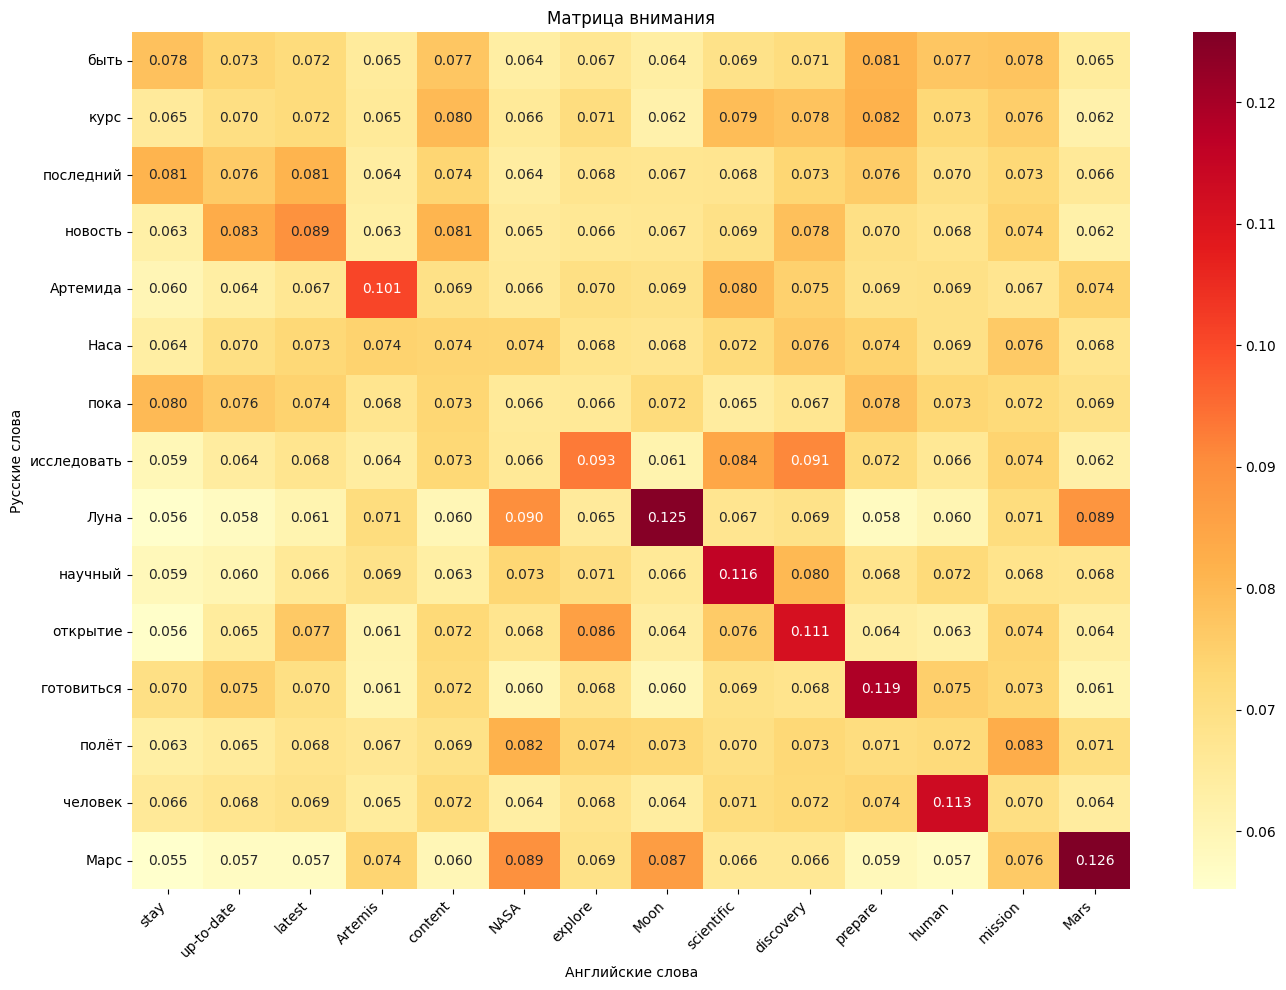

In [31]:
plt.figure(figsize=(14, 10))
sns.heatmap(attention,
            xticklabels=lemmatized_en,
            yticklabels=lemmatized_ru,
            cmap='YlOrRd',
            annot=True,
            fmt='.3f',
            square=False)
plt.title('Матрица внимания')
plt.xlabel('Английские слова')
plt.ylabel('Русские слова')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [32]:
expected_pairs = {
    'Артемида': 'artemis',
    'Наса': 'nasa',
    'Марс': 'mars',
    'Луна': 'moon',
    'исследовать': 'explore',
    'открытие': 'discovery',
    'готовиться': 'prepare',
    'человек': 'human',
    'полёт': 'mission',
    'научный': 'scientific',
    'последний': 'latest',
    'новость': 'content',
    'быть': 'stay',
}

correct = 0
print("\nРусское слово → Английское (вес) [статус]")
print("-" * 50)

for ru_word, expected_en in expected_pairs.items():
    if ru_word in lemmatized_ru and expected_en in lemmatized_en:
        i = lemmatized_ru.index(ru_word)
        j = lemmatized_en.index(expected_en)
        weight = attention[i, j]

        is_top = np.argmax(attention[i]) == j

        if is_top:
            status = "good"
            correct += 1
        elif weight > 0.1:
            status = "norma"
        else:
            status = "bad"

        print(f"  {ru_word:12s} → {expected_en:12s}: {weight:.3f}  {status}")

print(f"\nЛучших связей: {correct}/{len(expected_pairs)}")


Русское слово → Английское (вес) [статус]
--------------------------------------------------
  исследовать  → explore     : 0.093  good
  открытие     → discovery   : 0.111  good
  готовиться   → prepare     : 0.119  good
  человек      → human       : 0.113  good
  полёт        → mission     : 0.083  good
  научный      → scientific  : 0.116  good
  последний    → latest      : 0.081  bad
  новость      → content     : 0.081  bad
  быть         → stay        : 0.078  bad

Лучших связей: 6/13


In [33]:
df = pd.DataFrame(columns=['news'])
df.loc[0] = ['''Chornobyl Exclusion Zone, Ukraine - It’s a freezing January morning, and the sun is glistening across a placid, snowy, forested landscape. But the calm is deceptive.An air raid siren suddenly blares across the crisp winter air.
Two soldiers scour the skies, hands firmly gripping anti-aircraft guns mounted on pick-up trucks parked on a small, dilapidated bridge on a tributary of the Pripyat River.
Danger is all around, both in the surrounding land, which still carries the legacy of the 1986 Chornobyl nuclear disaster, with pockets of intense radioactive contamination, and above, where Russian drones and missiles launched from just across the border in Belarus, a short distance to the north, regularly pass overhead.The area is known as the Chornobyl Exclusion Zone (CEZ), a restricted area of approximately 30km (19 miles) in diameter, comparable in size to Luxembourg, established to contain the spread of contamination.
Since Russia launched its full-scale invasion of Ukraine on February 24, 2022, briefly occupying the CEZ and the surrounding area, large swaths of it have become militarised, adding another layer of restriction to an already tightly controlled and hazardous environment.
Yet despite the CEZ’s many dangers, four decades on from the Chornobyl disaster, small communities of scientists, elderly returnees and soldiers have carved out lives among its abandoned buildings, while wildlife thrives in the surrounding forests.''']
df.loc[1] = ['''MOSCOW, April 24 (Reuters) - Russian President Vladimir Putin's approval ​rating has fallen for a seventh week in a row to 65.6%, its lowest level ‌since the invasion of Ukraine in February 2022, according to state pollster VTsIOM.
Russia's paramount leader, who was appointed acting president by Boris Yeltsin just eight years after the fall of the Soviet Union, has ruled the country since 1999 either ​as president or prime minister.A former KGB lieutenant colonel who watched the Soviet Union collapse while ​based in East Germany, Putin will overtake Josef Stalin and become Russia's longest-serving ⁠ruler since Empress Catherine the Great if he completes his current six-year term.
But his ratings, though still ​high by Western standards, have taken a hit in recent weeks. Putin's approval rating is down from 73.3% ​in March, while trust in him has slipped over the same period to 71% from above 77%, according to VTsIOM.residence outside Moscow, Russia, April 17, 2026.... Purchase Licensing Rights, opens new tab Read more
MOSCOW, April 24 (Reuters) - Russian President Vladimir Putin's approval ​rating has fallen for a seventh week in a row to 65.6%, its lowest level ‌since the invasion of Ukraine in February 2022, according to state pollster VTsIOM.
Russia's paramount leader, who was appointed acting president by Boris Yeltsin just eight years after the fall of the Soviet Union, has ruled the country since 1999 either ​as president or prime minister.
The Reuters Iran Briefing newsletter keeps you informed with the latest developments and analysis of the Iran war. Sign up here.
A former KGB lieutenant colonel who watched the Soviet Union collapse while ​based in East Germany, Putin will overtake Josef Stalin and become Russia's longest-serving ⁠ruler since Empress Catherine the Great if he completes his current six-year term.
But his ratings, though still ​high by Western standards, have taken a hit in recent weeks. Putin's approval rating is down from 73.3% ​in March, while trust in him has slipped over the same period to 71% from above 77%, according to VTsIOM.
Advertisement · Scroll to continue
It was not immediately clear why Putin's rating, though still very high, was falling. Last week he ordered his top officials ​to come up with ways to kick-start the economy after a contraction in the first two months of ​the year.
A crackdown on the mobile internet, messengers and VPNs has caused frustration for many Russians in the past few months.
Putin ‌said on ⁠Thursday that the internet outages were necessary for security reasons, but that law enforcement officials must show "ingenuity" to find solutions and guarantee the functioning of vital services.''']
df.loc[2] = ['''A large ice block on the route just above the Mount Everest base camp has forced hundreds of climbers and local guides to delay their attempt to scale the world’s highest peak.
The serac between base camp and camp one was unstable and risky for climbers, said Himal Gautam of Nepal’s department of mountaineering on Friday.
Officials were working with climbers and expedition organisers to assess the situation as climbers waited at base camp.
According to the department, 410 foreign climbers had been issued permits to attempt to reach the Everest summit during the spring climbing season, which closes at the end of May.
“Icefall doctors”, elite guides who lay the yearly climbing route by setting ropes and securing aluminium ladders over crevasses, usually finish the task by mid-April.
The Sagarmatha pollution control committee, which deploys teams to lay the route, said it planned to assess the serac by aerial survey. The risk of avalanche was high and they were waiting for the serac to melt down to a safe level, the committee’s chair, Lama Kazi Sherpa, said.
The serac is part of the Khumbu icefall, a constantly shifting glacier with deep crevasses and huge overhanging ice that can be as big as 10-storey buildings. It is considered one of the hardest and trickiest sections of the climb.
In 2014, a chunk of the glacier sheared away from the mountain, setting off an avalanche of ice that killed 16 Sherpa guides as they carried clients’ equipment up the mountain. It was one of the deadliest disasters in Everest climbing history.
Hundreds of foreign climbers and about the same number of Nepalese guides and helpers are expected to attempt to scale the mountain next month when there are a few brief windows of favourable weather.
Thousands of people have reached the summit of the 8,849-metre (29,032-ft) peak since it was first reached on 29 May 1953 by the Sherpa guide Tenzing Norgay and the New Zealander Edmund Hillary.''']
df.loc[3] = ['''PARIS — France removed climate change from the agenda of this week's G7 talks to prevent a rift with the United States, according to a French government official.
Environment ministers from the G7 nations are meeting in Paris Thursday and Friday to discuss issues ranging from biodiversity to water resources.
But the French hosts deliberately avoided putting global warming on the agenda to appease the U.S. administration of President Donald Trump, who has dismissed climate change as a "con job" and withdrawn his country from several international climate bodies."We have chosen not to tackle the climate issue head-on," an adviser to French Ecological Transition Minister Monique Barbut told reporters. "Why? Because the United States’ positions on this issue are well known, and we felt ... that tackling this issue head-on with the United States within the G7 framework would not send a message of unity."
"We chose to focus on less contentious issues," said the adviser, who briefed reporters on condition of anonymity.
Despite those efforts, the U.S. chose not to send a high-level representative to Paris. Washington is represented instead by Usha-Maria Turner, an assistant administrator at the U.S. Environmental Protection Agency. The other six countries sent their ministers.
"The French government’s approach is understandable," said a government official from Germany, whose Environment Minister Carsten Schneider traveled to Paris for the meeting.
"In addition to the climate crisis, there are many other environmental issues with global implications, including the protection of water resources and biodiversity," the official said. "It's important that the U.S. is kept engaged in the relevant international negotiations on solutions in these areas."
"The U.S. government has at least now been persuaded to convene a separate G20 meeting of environment ministers," the official added. The U.S. currently holds the G20 presidency. An environment ministerial is not yet on the public calendar.Climate campaigners, however, lambasted France's stance, especially given Barbut's complaints about the outcome of last year's COP climate talks as not ambitious enough.
“It’s a paradox to lament the outcome of the COP but when you’re in control of the agenda not use it to address the elephant in the room," said Fanny Petitbon, France team lead of nonprofit 350.org. "For us, it’s a huge disappointment.”
A version of this article was first published by POLITICO in French. ''']
df.loc[4] = ['''Norway plans to restrict access to social media for children under 16, joining a growing number of countries responding to concerns about the potential harm kids face online.
The bill comes after “overwhelming” demand from the public, the government said Friday. It plans to bring the legislation to parliament before the end of the year.
The limit will apply up until January 1 the year a child turns 16 with technology companies responsible for age verification, the government said.
“We want a childhood where children get to be children,” Prime Minister Jonas Gahr Store said in the statement. “Play, friendships, and everyday life must not be taken over by algorithms and screens.”
The Nordic nation’s move follows on the heels of bans instituted recently in Australia and Greece, with multiple other nations considering similar action. Australia’s restrictions came into force in December, with 4.7 million accounts held by young users affected. Greece will end access to social media for children under 15 from the start of next year."
American scientists attempted to grow chickpeas on soil that simulates lunar regolith.
Scientists grew chickpeas on soil mixtures where the proportion of regolith reached up to 75%. It was found that the higher the percentage of lunar soil in the mixture, the lower the yield. At the same time, the size of the grains themselves did not change. However, seeds planted in pure lunar soil simulant (100%) failed to bloom and produce seeds. The plants died at early stages of development. Lunar regolith and its simulant contain high amounts of iron and aluminum. Iron is beneficial for plants, but aluminum is not. Additionally, the grown chickpeas will need to be tested for metal content. “Children cannot be left with the responsibility for staying away from platforms they are not allowed to use,” Karianne Tung, Norway’s minister of digitalization, said in the statement. “That responsibility rests with the companies providing these services.”Once a first mover when it came to giving kids access to iPads and smart phones, Norway has in recent years sought to cut back on usage. It has recommended all class rooms be mobile-free since 2024, quoting surveys that suggest access to the devices undermines concentration and results in poor learning outcomes. The city of Oslo has banned mobile phones in all schools, while letting high school students use them on breaks.
YouTube Inc said it believes in “protecting youth in the digital world, not from it,” and that it supports a “comprehensive approach to ensure that platforms are incentivized to build safer, age-appropriate experiences that also empowers parents,” according to an emailed statement. The company said it will continue to “engage constructively” with the government.
French President Emmanuel Macron said last week that Europe must come up with a cohesive approach to protecting children online as the European Union grapples with how to regulate social networks. Proposals thus far have varied widely, with different minimum ages and systems to protect children. Norway, which is not a member of the EU, said its proposals align with plans by the bloc.
The movement is gaining momentum across the region. Last week, UK Prime Minister Keir Starmer met with officials from Meta Platforms Inc, Alphabet Inc., Elon Musk’s X Corp., Bytedance Co.’s TikTok and Snap Inc. that owns Snapchat, calling on them to demonstrate how their products can be made safer for children. Spanish Prime Minister Pedro Sánchez has described social media as a “failed state.”''']
df.loc[6] = ['''US President Donald Trump has "permanently" opened the Strait of Hormuz — the most important logistics artery through which a large share of global oil and gas trade routes pass — to the entire world. According to Trump, he did this for the sake of China, which allegedly agreed to stop supplying weapons to Iran. The reaction from the international community, experts, and ordinary citizens has been mixed — ranging from harsh statements from Iran to ironic comments on social media.
Earlier, the American leader intended to pressure Tehran in negotiations using a blockade, but the idea turned out to be a failure — Iranian ships continued to sail through the waters of Hormuz as they always had. Meanwhile, ongoing military actions around the strait have already led to the largest price shock in the global oil market in decades. Details of Trump's final decision and the reaction of Iran, the US, and Russia to it, as well as an assessment of the consequences of what is happening in the Middle East on the urgent market. Alternative oil grades, including Texas WTI and Russian Urals, have become more expensive than North Sea Brent.
For example, on April 2, the price of Brent oil on the spot market rose above $140 per barrel (to $141) for the first time since 2008, increasing by almost 11% since the beginning of the month, and nearly doubled since the beginning of spring. This is the strongest increase since the third quarter of ''']
df.loc[7] = ['''The closure of the Strait of Hormuz caused an oil shortage, leading to a significant divergence in prices between the spot and futures markets. Alternative oil grades, including Texas WTI and Russian Urals, have become more expensive than North Sea Brent.
For example, on April 2, the price of Brent oil on the spot market rose above $140 per barrel (to $141) for the first time since 2008, increasing by almost 11% since the beginning of the month, and nearly doubled since the beginning of spring. This is the strongest increase since the third quarter of 1990 (the Kuwait war).
According to the International Energy Agency, the blockade of the strait has become the largest supply disruption in the history of the industry. According to Goldman Sachs estimates, the total damage to oil flows from the Persian Gulf amounted to 17.7 million barrels per day, or 18% of global oil consumption.
Investors' willingness to pay a significant premium for oil delivery within a few days indicates a shortage of crude. The divergence between spot and futures prices is a classic hard backwardation, which typically occurs when refiners and traders fear supply disruptions and there are few available free cargoes.
Analysts believe that further price dynamics will depend on the success of US-Iran negotiations and the speed of recovery of raw material supplies through the Strait of Hormuz. If the current de-escalation holds and supplies through the strait steadily recover, the extreme premium for non-Middle Eastern oil will begin to decline. However, even in that case, the deficit that formed during March and April will continue to pressure oil supply and support high prices.''']

print(df)

                                                news
0  Chornobyl Exclusion Zone, Ukraine - It’s a fre...
1  MOSCOW, April 24 (Reuters) - Russian President...
2  A large ice block on the route just above the ...
3  PARIS — France removed climate change from the...
4  Norway plans to restrict access to social medi...
6  US President Donald Trump has "permanently" op...
7  The closure of the Strait of Hormuz caused an ...


In [50]:
from transformers import T5Tokenizer, T5ForConditionalGeneration

In [51]:
model_name = "t5-small"
tokenizer = T5Tokenizer.from_pretrained(model_name)

In [52]:
def summarize_news(text, max_length=100):
    if pd.isna(text) or len(str(text)) < 50:
        return ""

    input_text = f"summarize: {str(text)[:500]}"

    inputs = tokenizer.encode(input_text, return_tensors="pt", max_length=512, truncation=True)

    summary_ids = model.generate(inputs,
                                 max_length=max_length,
                                 min_length=30,
                                 num_beams=4,
                                 early_stopping=True)

    summary = tokenizer.decode(summary_ids[0], skip_special_tokens=True)

    return summary

In [53]:
df['summary'] = df['news'].apply(summarize_news)

for i in range(len(df)):
    print(f"\n news {i+1}")
    print(f"Оригинал: {str(df.iloc[i]['news'])[:150]}...")
    print(f"Саммари: {df.iloc[i]['summary']}")
    print("-"*50)


 news 1
Оригинал: Chornobyl Exclusion Zone, Ukraine - It’s a freezing January morning, and the sun is glistening across a placid, snowy, forested landscape. But the cal...
Саммари: air raid siren suddenly blares across the crisp winter air. two soldiers scour the skies, hands firmly gripping anti-aircraft guns mounted on pick-up trucks parked on a small, dilapidated bridge.
--------------------------------------------------

 news 2
Оригинал: MOSCOW, April 24 (Reuters) - Russian President Vladimir Putin's approval ​rating has fallen for a seventh week in a row to 65.6%, its lowest level ‌si...
Саммари: the approval rating has fallen for a seventh week in a row to 65.6%, its lowest level since the invasion of Ukraine in february 2022. a former KGB lieutenant colonel who watched the Soviet Union colt watched the Soviet Union colt.
--------------------------------------------------

 news 3
Оригинал: A large ice block on the route just above the Mount Everest base camp has forced hundred

In [76]:
def get_summary_metrics(original, summary):
    orig_words = len(original.split())
    summ_words = len(summary.split())

    return {
        'orig_len': orig_words,
        'summ_len': summ_words,
        'compression': orig_words / summ_words if summ_words > 0 else 0,
        'density': summ_words / orig_words if orig_words > 0 else 0
    }

for i in range(len(df)):
    metrics = get_summary_metrics(df.iloc[i]['news'], df.iloc[i]['summary'])

    print(f"\n news {i+1}")
    print(f"{metrics['orig_len']} слов → {metrics['summ_len']} слов | Сжатие: {metrics['compression']:.1f}:1 | {metrics['density']:.1%} от оригинала")


 news 1
220 слов → 30 слов | Сжатие: 7.3:1 | 13.6% от оригинала

 news 2
435 слов → 41 слов | Сжатие: 10.6:1 | 9.4% от оригинала

 news 3
327 слов → 25 слов | Сжатие: 13.1:1 | 7.6% от оригинала

 news 4
382 слов → 34 слов | Сжатие: 11.2:1 | 8.9% от оригинала

 news 5
573 слов → 35 слов | Сжатие: 16.4:1 | 6.1% от оригинала

 news 6
248 слов → 37 слов | Сжатие: 6.7:1 | 14.9% от оригинала

 news 7
273 слов → 28 слов | Сжатие: 9.8:1 | 10.3% от оригинала


In [56]:
from transformers import pipeline

In [58]:
classifier = pipeline("zero-shot-classification",
                      model="facebook/bart-large-mnli")

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

In [61]:
categories = ["Politics", "Technology", "Science", "Business", "Sports",
              "Entertainment", "Environment", "War", "Space", "Health"]

In [62]:
def get_category(text):
    result = classifier(str(text)[:1000], candidate_labels=categories)
    return result['labels'][0]


In [63]:
def get_confidence(text):
    result = classifier(str(text)[:1000], candidate_labels=categories)
    return result['scores'][0]

In [65]:
df['category'] = df['news'].apply(get_category)
df['confidence'] = df['news'].apply(get_confidence)

In [66]:
df

,news,summary,category,confidence
0,"Chornobyl Exclusion Zone, Ukraine - It’s a fre...",air raid siren suddenly blares across the cris...,Environment,0.131458
1,"MOSCOW, April 24 (Reuters) - Russian President...",the approval rating has fallen for a seventh w...,Entertainment,0.202919
2,A large ice block on the route just above the ...,the serac between base camp and camp one was u...,Technology,0.157892
3,PARIS — France removed climate change from the...,france removed climate change from the agenda ...,Environment,0.364803
4,Norway plans to restrict access to social medi...,the limit will apply up until January 1 the ye...,Politics,0.173956
6,"US President Donald Trump has ""permanently"" op...","he opened the Strait of Hormuz, the most impor...",Politics,0.365432
7,The closure of the Strait of Hormuz caused an ...,the closure of the Strait of Hormuz caused an ...,Business,0.186826


In [68]:
ner_model = pipeline("ner", model="dslim/bert-base-NER", aggregation_strategy="simple")


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForTokenClassification LOAD REPORT from: dslim/bert-base-NER
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.weight | UNEXPECTED |  | 
bert.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [74]:
for i, row in df.iterrows():
    print(f"\n news {i+1}")
    print(f"Текст: {row['news'][:100]}...")

    entities = ner_model(row['news'][:1000])

    if entities:
        unique = {}
        for e in entities: # -дубликаты
            if e['word'] not in unique or e['score'] > unique[e['word']]['score']:
                unique[e['word']] = e

        types = {}
        for e in unique.values():
            types[e['entity_group']] = types.get(e['entity_group'], 0) + 1

        print(f"{len(unique)} уникальных сущностей | Типы: {', '.join([f'{k}({v})' for k,v in types.items()])}")
        print(f"Средняя уверенность: {sum(e['score'] for e in unique.values())/len(unique):.2f}")

        print("", ', '.join([f"{e['word']}({e['entity_group']})" for e in unique.values()]))



 news 1
Текст: Chornobyl Exclusion Zone, Ukraine - It’s a freezing January morning, and the sun is glistening acros...
10 уникальных сущностей | Типы: LOC(9), MISC(1)
Средняя уверенность: 0.95
 Chornobyl Exclusion Zone(LOC), Ukraine(LOC), P(LOC), ##ripyat River(LOC), Chornobyl(LOC), Russian(MISC), Belarus(LOC), CEZ(LOC), Luxembourg(LOC), Russia(LOC)

 news 2
Текст: MOSCOW, April 24 (Reuters) - Russian President Vladimir Putin's approval ​rating has fallen for a se...
18 уникальных сущностей | Типы: LOC(6), ORG(5), MISC(2), PER(5)
Средняя уверенность: 0.97
 MOSCO(LOC), Reuters(ORG), Russian(MISC), Vladimir Putin(PER), Ukraine(LOC), V(ORG), ##TsIOM(ORG), Russia(LOC), Boris Yeltsin(PER), Soviet Union(LOC), KGB(ORG), East Germany(LOC), Putin(PER), Josef Stalin(PER), Catherine(PER), Western(MISC), VTsIOM(ORG), Moscow(LOC)

 news 3
Текст: A large ice block on the route just above the Mount Everest base camp has forced hundreds of climber...
6 уникальных сущностей | Типы: LOC(3), PER(2), ORG